# Benchmark: `call_peaks_bdg` (methylation) vs ATAC-seq peaks

Cell type: **STR D2_MSN** (hg38).

`cytozip.call_peaks_bdg` calls peaks from snm3C-seq CpG **hypomethylation**
(`umc = cov - mc`) as an ATAC-like open-chromatin signal. This notebook
benchmarks those peaks against matched **ATAC-seq** peaks (treated as the
open-chromatin ground truth).

**Inputs**
- ATAC peaks: `~/Projects/BG/atac/Subclass.peaks/STR_D2_MSN.macs3.peak.tsv`
- Meth peaks: `~/Projects/BG/pseudobulk/Subclass/D2_MSN_peaks/D2_MSN_peaks.narrowPeak`
- Blacklist: `~/Ref/hg38/annotations/hg38-blacklist.v2.bed.gz`
- GTF: `~/Ref/hg38/annotations/gencode.v43.annotation.gtf`
- Chrom sizes: `~/Ref/hg38/hg38_ucsc.main.chrom.sizes`

**Metrics**: basic peak stats, ENCODE blacklist QC, precision / recall / F1 /
bp-Jaccard against ATAC, precision-recall vs significance cutoff, and TSS /
genomic-annotation distributions. All interval operations are implemented in
numpy (no `bedtools` dependency).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.width', 120)

ATAC_PEAKS = os.path.expanduser('~/Projects/BG/atac/Subclass.peaks/STR_D2_MSN.macs3.peak.tsv')
METH_DIR = os.path.expanduser('~/Projects/BG/pseudobulk/Subclass/D2_MSN_peaks')
METH_PEAKS = os.path.join(METH_DIR, 'D2_MSN_peaks.narrowPeak')
BLACKLIST = os.path.expanduser('~/Ref/hg38/annotations/hg38-blacklist.v2.bed.gz')
GTF = os.path.expanduser('~/Ref/hg38/annotations/gencode.v43.annotation.gtf')
CHROM_SIZES = os.path.expanduser('~/Ref/hg38/hg38_ucsc.main.chrom.sizes')

sizes = pd.read_csv(CHROM_SIZES, sep='\t', header=None, names=['chrom', 'size'])
MAIN_CHROMS = list(sizes['chrom'])
GENOME_BP = int(sizes['size'].sum())
print(f'{len(MAIN_CHROMS)} main chromosomes; genome = {GENOME_BP/1e9:.3f} Gb')

25 main chromosomes; genome = 3.088 Gb


## 1. Load peak sets

Both files use narrowPeak column semantics (BED6+4). The ATAC TSV carries a
header row; the meth narrowPeak does not — the loader auto-detects it. `pValue`
is the MACS3/ENCODE convention `-log10(p)` in both. `summit = start + peak`.

In [2]:
NP_COLS = ['chrom', 'start', 'end', 'name', 'score', 'strand',
           'signalValue', 'pValue', 'qValue', 'peak']

def load_narrowpeak(path):
    with open(path) as fh:
        first = fh.readline().split('\t')[0].strip()
    has_header = first.lower() == 'chrom'
    df = pd.read_csv(path, sep='\t', header=0 if has_header else None,
                     names=None if has_header else NP_COLS)
    df.columns = NP_COLS[:df.shape[1]]
    df = df[df['chrom'].isin(MAIN_CHROMS)].copy()
    df['start'] = df['start'].astype(np.int64)
    df['end'] = df['end'].astype(np.int64)
    df['peak'] = pd.to_numeric(df['peak'], errors='coerce')
    df['peak'] = df['peak'].fillna((df['end'] - df['start']) // 2).astype(np.int64)
    df['summit'] = df['start'] + df['peak'].clip(lower=0)
    df['width'] = df['end'] - df['start']
    df['pValue'] = pd.to_numeric(df['pValue'], errors='coerce').fillna(-1.0)
    return df.reset_index(drop=True)

atac = load_narrowpeak(ATAC_PEAKS)
meth = load_narrowpeak(METH_PEAKS)
print('ATAC peaks:', len(atac))
print('Meth (call_peaks_bdg) peaks:', len(meth))
meth.head()

ATAC peaks: 377085
Meth (call_peaks_bdg) peaks: 189633


,chrom,start,end,name,score,strand,signalValue,pValue,qValue,peak,summit,width
0,chr1,28716,29652,D2_MSN_peak_1,1000,.,1.15377,205.24357,-1,649,29365,936
1,chr1,48033,48333,D2_MSN_peak_2,1000,.,1.59883,174.41118,-1,298,48331,300
2,chr1,86772,87095,D2_MSN_peak_3,1000,.,1.40213,118.19726,-1,66,86838,323
3,chr1,91042,91731,D2_MSN_peak_4,1000,.,1.46969,3100.00000,-1,168,91210,689
4,chr1,113825,114125,D2_MSN_peak_5,770,.,1.48602,77.08503,-1,125,113950,300


## 2. Interval helpers (numpy)

`overlap_mask` — for each interval in `a`, does it overlap any interval in `b`?
Per chromosome, `b` is sorted by start and a prefix-max of ends lets a single
`searchsorted` decide overlap in `O(n log n)`. `jaccard` computes the
base-pair intersection / union between the two peak sets via a coordinate
sweep on their merged coverages.

In [3]:
def overlap_mask(a, b):
    a = a.reset_index(drop=True)
    mask = np.zeros(len(a), dtype=bool)
    b_groups = {c: (g['start'].to_numpy(), g['end'].to_numpy())
                for c, g in b.groupby('chrom', sort=False)}
    for chrom, ga in a.groupby('chrom', sort=False):
        gb = b_groups.get(chrom)
        if gb is None:
            continue
        bs, be = gb
        o = np.argsort(bs, kind='mergesort')
        bs, be = bs[o], be[o]
        cend = np.maximum.accumulate(be)          # prefix-max of ends
        a_s = ga['start'].to_numpy()
        a_e = ga['end'].to_numpy()
        k = np.searchsorted(bs, a_e, side='left')  # b with start < a_end
        hit = k > 0
        idx = np.clip(k - 1, 0, len(bs) - 1)
        res = np.zeros(len(ga), dtype=bool)
        res[hit] = cend[idx[hit]] > a_s[hit]
        mask[ga.index.to_numpy()] = res
    return mask

def _merge(s, e):
    o = np.argsort(s, kind='mergesort')
    s, e = s[o], e[o]
    cple = np.maximum.accumulate(e)
    new = np.empty(len(s), dtype=bool)
    new[0] = True
    new[1:] = s[1:] > cple[:-1]
    starts = s[new]
    ends = np.maximum.reduceat(e, np.flatnonzero(new))
    return starts, ends

def merged_coverage(df):
    total = 0
    per = {}
    for chrom, g in df.groupby('chrom', sort=False):
        ms, me = _merge(g['start'].to_numpy(), g['end'].to_numpy())
        per[chrom] = (ms, me)
        total += int((me - ms).sum())
    return total, per

def _both_bp(a_s, a_e, b_s, b_e):
    pos = np.concatenate([a_s, a_e, b_s, b_e]).astype(np.int64)
    da = np.concatenate([np.ones(len(a_s)), -np.ones(len(a_e)),
                         np.zeros(len(b_s) + len(b_e))])
    db = np.concatenate([np.zeros(len(a_s) + len(a_e)),
                         np.ones(len(b_s)), -np.ones(len(b_e))])
    o = np.argsort(pos, kind='mergesort')
    pos, da, db = pos[o], da[o], db[o]
    covA = np.cumsum(da)[:-1]
    covB = np.cumsum(db)[:-1]
    seg = np.diff(pos)
    both = (covA > 0) & (covB > 0)
    return int(seg[both].sum())

def jaccard(df_a, df_b):
    a_bp, perA = merged_coverage(df_a)
    b_bp, perB = merged_coverage(df_b)
    inter = 0
    for c in set(perA) & set(perB):
        as_, ae = perA[c]
        bs_, be = perB[c]
        inter += _both_bp(as_, ae, bs_, be)
    union = a_bp + b_bp - inter
    return (inter / union if union else 0.0), inter, a_bp, b_bp

## 3. Basic peak statistics

,set,n_peaks,median_width,mean_width,total_bp_merged,genome_frac_%
0,ATAC,377085,706,860.6,173480167,5.617
1,Meth_bdg,189633,462,631.1,119672642,3.875


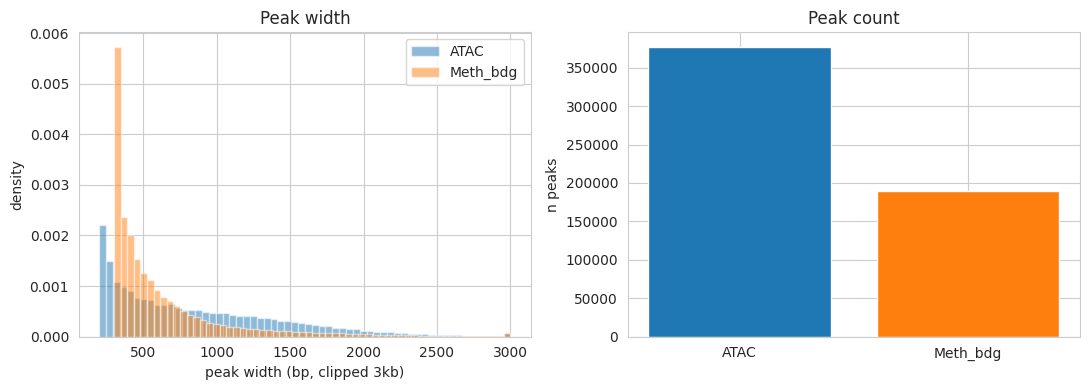

In [4]:
def stats_row(name, df):
    cov, _ = merged_coverage(df)
    return {'set': name, 'n_peaks': len(df),
            'median_width': int(df['width'].median()),
            'mean_width': round(float(df['width'].mean()), 1),
            'total_bp_merged': cov,
            'genome_frac_%': round(100 * cov / GENOME_BP, 3)}

stats = pd.DataFrame([stats_row('ATAC', atac), stats_row('Meth_bdg', meth)])
display(stats)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for name, df, c in [('ATAC', atac, 'C0'), ('Meth_bdg', meth, 'C1')]:
    ax[0].hist(np.clip(df['width'], 0, 3000), bins=60, alpha=0.5,
               label=name, color=c, density=True)
ax[0].set(xlabel='peak width (bp, clipped 3kb)', ylabel='density', title='Peak width')
ax[0].legend()
ax[1].bar(stats['set'], stats['n_peaks'], color=['C0', 'C1'])
ax[1].set(ylabel='n peaks', title='Peak count')
plt.tight_layout()
plt.show()

## 4. Blacklist QC

Fraction of peaks overlapping ENCODE hg38 blacklist regions (a low value is a
quality signal). Blacklisted peaks are removed from both sets before the
concordance analysis below.

In [5]:
bl = pd.read_csv(BLACKLIST, sep='\t', header=None, usecols=[0, 1, 2],
                 names=['chrom', 'start', 'end'])
bl = bl[bl['chrom'].isin(MAIN_CHROMS)].reset_index(drop=True)

atac_bl = overlap_mask(atac, bl)
meth_bl = overlap_mask(meth, bl)
print(f'ATAC in blacklist: {atac_bl.sum()} ({100*atac_bl.mean():.2f}%)')
print(f'Meth in blacklist: {meth_bl.sum()} ({100*meth_bl.mean():.2f}%)')

atac_f = atac[~atac_bl].reset_index(drop=True)
meth_f = meth[~meth_bl].reset_index(drop=True)
print('After blacklist removal -> ATAC:', len(atac_f), '| Meth:', len(meth_f))

ATAC in blacklist: 1983 (0.53%)
Meth in blacklist: 16383 (8.64%)
After blacklist removal -> ATAC: 375102 | Meth: 173250


## 5. Concordance with ATAC

- **precision** = fraction of meth peaks overlapping an ATAC peak
- **recall** = fraction of ATAC peaks recovered by a meth peak
- **Jaccard** = base-pair intersection / union of the two peak sets

,precision (meth in ATAC),recall (ATAC in meth),F1,Jaccard (bp),intersect_Mb
0,0.7054,0.5501,0.6181,0.3725,77.03


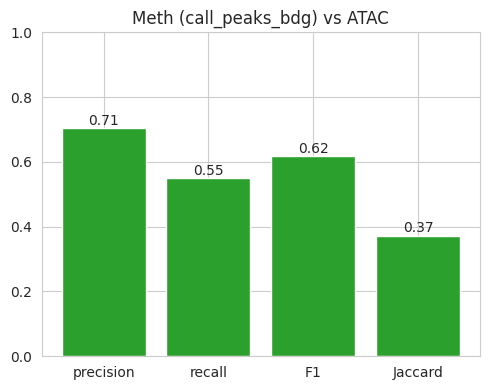

In [6]:
meth_ov = overlap_mask(meth_f, atac_f)
atac_ov = overlap_mask(atac_f, meth_f)

precision = float(meth_ov.mean())
recall = float(atac_ov.mean())
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
jac, inter_bp, a_bp, b_bp = jaccard(atac_f, meth_f)

summary = pd.DataFrame([{
    'precision (meth in ATAC)': round(precision, 4),
    'recall (ATAC in meth)': round(recall, 4),
    'F1': round(f1, 4),
    'Jaccard (bp)': round(jac, 4),
    'intersect_Mb': round(inter_bp / 1e6, 2),
}])
display(summary)

fig, ax = plt.subplots(figsize=(5, 4))
vals = [precision, recall, f1, jac]
ax.bar(['precision', 'recall', 'F1', 'Jaccard'], vals, color='C2')
ax.set(ylim=(0, 1), title='Meth (call_peaks_bdg) vs ATAC')
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()

## 6. Precision / recall vs significance cutoff

Meth peaks are thresholded on `pValue` (`-log10 p`). A higher cutoff keeps
fewer, more confident peaks: precision should rise and recall fall. This shows
whether the peak **ranking** is informative.

,pValue_cutoff,n_meth,precision,recall
0,0,173250,0.7054,0.5501
1,2,173250,0.7054,0.5501
2,5,173250,0.7054,0.5501
3,10,173250,0.7054,0.5501
4,20,173250,0.7054,0.5501
5,50,173250,0.7054,0.5501
6,100,162122,0.7306,0.5370
7,200,115992,0.8338,0.4570
8,500,80375,0.9038,0.3588


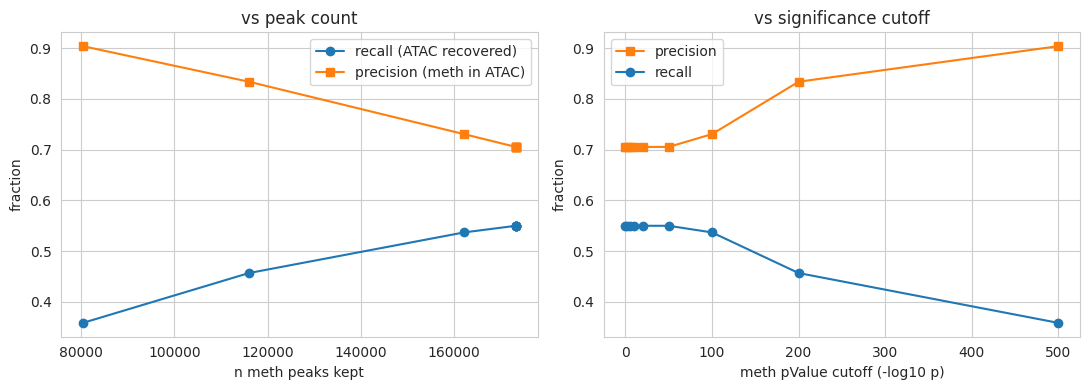

In [7]:
cutoffs = [0, 2, 5, 10, 20, 50, 100, 200, 500]
rows = []
for t in cutoffs:
    sub = meth_f[meth_f['pValue'] >= t]
    if len(sub) == 0:
        continue
    rows.append({'pValue_cutoff': t, 'n_meth': len(sub),
                 'precision': float(overlap_mask(sub, atac_f).mean()),
                 'recall': float(overlap_mask(atac_f, sub).mean())})
sat = pd.DataFrame(rows)
display(sat.round(4))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(sat['n_meth'], sat['recall'], 'o-', label='recall (ATAC recovered)')
ax[0].plot(sat['n_meth'], sat['precision'], 's-', label='precision (meth in ATAC)')
ax[0].set(xlabel='n meth peaks kept', ylabel='fraction', title='vs peak count')
ax[0].legend()
ax[1].plot(sat['pValue_cutoff'], sat['precision'], 's-', color='C1', label='precision')
ax[1].plot(sat['pValue_cutoff'], sat['recall'], 'o-', color='C0', label='recall')
ax[1].set(xlabel='meth pValue cutoff (-log10 p)', ylabel='fraction', title='vs significance cutoff')
ax[1].legend()
plt.tight_layout()
plt.show()

## 7. TSS distance & genomic annotation

TSS are taken from GENCODE v43 gene records (strand-aware). We compare how
close each peak's summit sits to the nearest TSS and how peaks partition into
promoter (`<=2kb` of a TSS) / gene body / intergenic.

genes: 62703
ATAC: <=1kb of TSS 11.8% | <=5kb 24.4%
Meth_bdg: <=1kb of TSS 10.0% | <=5kb 22.0%


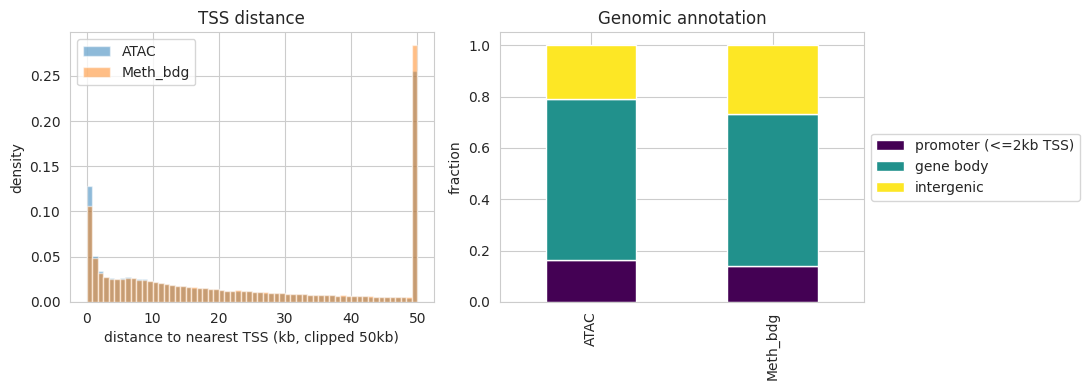

,ATAC,Meth_bdg
promoter (<=2kb TSS),0.161,0.140
gene body,0.630,0.594
intergenic,0.209,0.267


In [8]:
gtf = pd.read_csv(GTF, sep='\t', comment='#', header=None,
                  usecols=[0, 2, 3, 4, 6],
                  names=['chrom', 'feature', 'start', 'end', 'strand'])
genes = gtf[(gtf['feature'] == 'gene') & (gtf['chrom'].isin(MAIN_CHROMS))].copy()
genes['start'] = genes['start'].astype(np.int64) - 1   # GTF 1-based -> 0-based
genes['end'] = genes['end'].astype(np.int64)
genes['tss'] = np.where(genes['strand'] == '+', genes['start'], genes['end'])
tss_by = {c: np.sort(g['tss'].to_numpy())
          for c, g in genes.groupby('chrom', sort=False)}
genes_iv = genes[['chrom', 'start', 'end']]
print('genes:', len(genes))

def nearest_tss(df):
    df = df.reset_index(drop=True)
    dist = np.full(len(df), np.iinfo(np.int64).max, dtype=np.int64)
    for chrom, g in df.groupby('chrom', sort=False):
        t = tss_by.get(chrom)
        if t is None or len(t) == 0:
            continue
        x = g['summit'].to_numpy()
        i = np.searchsorted(t, x)
        il = np.clip(i - 1, 0, len(t) - 1)
        ir = np.clip(i, 0, len(t) - 1)
        d = np.minimum(np.abs(x - t[il]), np.abs(x - t[ir]))
        dist[g.index.to_numpy()] = d
    return dist

atac_d = nearest_tss(atac_f)
meth_d = nearest_tss(meth_f)
for name, d in [('ATAC', atac_d), ('Meth_bdg', meth_d)]:
    print(f'{name}: <=1kb of TSS {100*np.mean(d<=1000):.1f}% | '
          f'<=5kb {100*np.mean(d<=5000):.1f}%')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for name, d, c in [('ATAC', atac_d, 'C0'), ('Meth_bdg', meth_d, 'C1')]:
    ax[0].hist(np.clip(d, 0, 50000) / 1000, bins=60, alpha=0.5,
               label=name, color=c, density=True)
ax[0].set(xlabel='distance to nearest TSS (kb, clipped 50kb)', ylabel='density',
          title='TSS distance')
ax[0].legend()

cats = {}
for name, df, d in [('ATAC', atac_f, atac_d), ('Meth_bdg', meth_f, meth_d)]:
    near = d <= 2000
    ingene = overlap_mask(df, genes_iv)
    cats[name] = [float(near.mean()),
                  float((ingene & ~near).mean()),
                  float((~ingene & ~near).mean())]
catdf = pd.DataFrame(cats, index=['promoter (<=2kb TSS)', 'gene body', 'intergenic'])
catdf.T.plot(kind='bar', stacked=True, ax=ax[1], colormap='viridis')
ax[1].set(ylabel='fraction', title='Genomic annotation')
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()
display(catdf.round(3))

## 8. Summary

- **Recall** = fraction of ATAC (open-chromatin) peaks the methylation caller
  recovers; **precision** = fraction of methylation peaks that are genuine
  (ATAC-supported). The precision/recall-vs-cutoff curve shows whether the
  `pValue` ranking is usable to trade one for the other.
- **Jaccard** summarises base-pair agreement; peak-count and width differences
  explain much of any precision gap (methylation peaks tend to be broader /
  more numerous).
- **TSS & annotation**: strong TSS enrichment and promoter fraction indicate
  the hypomethylation signal is capturing real regulatory elements. Compare the
  methylation profile against ATAC as the reference shape.

To benchmark another cell type, change `ATAC_PEAKS` / `METH_PEAKS` in the
config cell and re-run.